In [1]:
# Hücre 1: Kütüphaneler ve MIT-BIH EKG verisini doğrudan PhysioNet'ten okuma
!pip install -q wfdb

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks

# PhysioNet MIT-BIH veri setinden 100 numaralı kaydı oku (indirme yapmadan doğrudan çeker)
record_name = '100'
record = wfdb.rdrecord(record_name, pn_dir='mitdb')
annotation = wfdb.rdann(record_name, 'atr', pn_dir='mitdb')

fs = record.fs # Örnekleme frekansı (360 Hz)
signal = record.p_signal[:, 0] # 1. kanal EKG sinyali (MLII)

print(f"Başarılı! Kayıt: {record_name}")
print(f"Örnekleme Frekansı: {fs} Hz")
print(f"Toplam Sinyal Uzunluğu: {len(signal)} örnek ({len(signal)/fs/60:.1f} dakika)")
print(f"Uzman Tarafından İşaretlenmiş Toplam Atım Sayısı: {len(annotation.sample)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 2.7 MB/s eta 0:00:00
Başarılı! Kayıt: 100
Örnekleme Frekansı: 360 Hz
Toplam Sinyal Uzunluğu: 650000 örnek (30.1 dakika)
Uzman Tarafından İşaretlenmiş Toplam Atım Sayısı: 2274


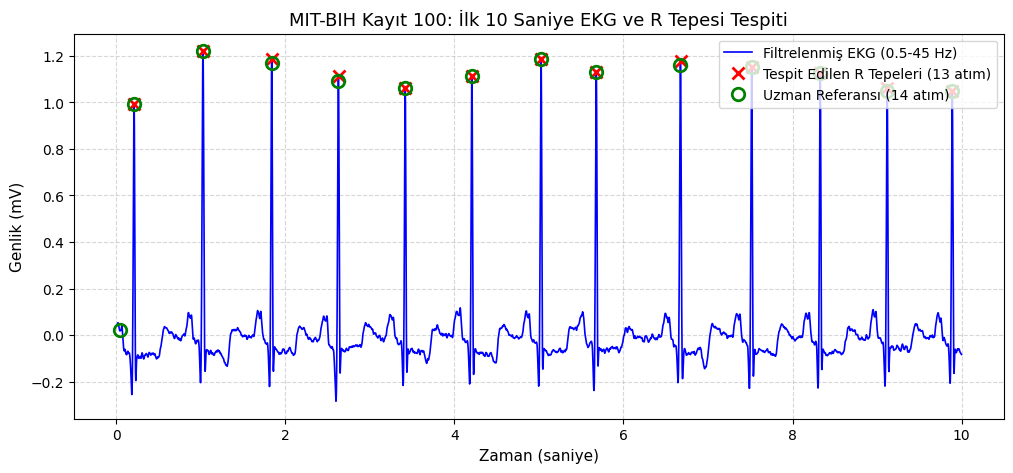

sekil1.png başarıyla kaydedildi!
İlk 10 saniyede tespit edilen R tepesi: 13
İlk 10 saniyede uzman referans atımı: 14


In [2]:
# Hücre 2: 0.5 - 45 Hz Bant Geçiren Filtre ve İlk Şekil (sekil1.png)

# 1. Butterworth Bant Geçiren Filtre (0.5 - 45 Hz, H5 konusu)
lowcut = 0.5
highcut = 45.0
nyq = 0.5 * fs
b, a = butter(2, [lowcut / nyq, highcut / nyq], btype='band')
filtered_signal = filtfilt(b, a, signal)

# 2. R Tepelerini Bulma (H1 konusu: en az 0.2 saniye mesafe)
min_distance = int(0.2 * fs) # 72 örnek
peaks, _ = find_peaks(filtered_signal, distance=min_distance, prominence=0.4)

# 3. İlk 10 Saniyeyi Çizdirme (sekil1.png)
süre_sn = 10
örnek_sayısı = int(süre_sn * fs)
t = np.arange(örnek_sayısı) / fs

# İlk 10 saniyedeki tespit edilen tepeler ve uzman etiketleri
p_10s = peaks[peaks < örnek_sayısı]
ref_10s = annotation.sample[annotation.sample < örnek_sayısı]

plt.figure(figsize=(12, 5))
plt.plot(t, filtered_signal[:örnek_sayısı], label='Filtrelenmiş EKG (0.5-45 Hz)', color='blue', lw=1.2)
plt.plot(t[p_10s], filtered_signal[p_10s], 'rx', markersize=9, markeredgewidth=2, label=f'Tespit Edilen R Tepeleri ({len(p_10s)} atım)')
plt.plot(ref_10s / fs, filtered_signal[ref_10s], 'go', fillstyle='none', markersize=9, markeredgewidth=2, label=f'Uzman Referansı ({len(ref_10s)} atım)')

plt.title('MIT-BIH Kayıt 100: İlk 10 Saniye EKG ve R Tepesi Tespiti', fontsize=13)
plt.xlabel('Zaman (saniye)', fontsize=11)
plt.ylabel('Genlik (mV)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

# Şekli kaydet (GitHub ve form için)
plt.savefig('sekil1.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"sekil1.png başarıyla kaydedildi!")
print(f"İlk 10 saniyede tespit edilen R tepesi: {len(p_10s)}")
print(f"İlk 10 saniyede uzman referans atımı: {len(ref_10s)}")

In [3]:
# Hücre 3: 5 EKG Kaydında Baseline ve İyileştirilmiş F1 Skoru Hesaplama

kayıt_listesi = ['100', '101', '102', '103', '105']

def f1_hesapla(tespit_edilen, gercek_etiketler, tol_ornek):
    """Her gerçek R tepesinin ±tol_ornek içinde tespit edilip edilmediğini kontrol eder"""
    if len(tespit_edilen) == 0:
        return 0.0, 0.0, 0.0

    tp = 0
    eslesen_tespit = set()

    for g in gercek_etiketler:
        farklar = np.abs(tespit_edilen - g)
        en_yakin_idx = np.argmin(farklar)
        if farklar[en_yakin_idx] <= tol_ornek and en_yakin_idx not in eslesen_tespit:
            tp += 1
            eslesen_tespit.add(en_yakin_idx)

    fp = len(tespit_edilen) - tp
    fn = len(gercek_etiketler) - tp

    duyarlilik = tp / (tp + fn) if (tp + fn) > 0 else 0
    kesinlik = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * (kesinlik * duyarlilik) / (kesinlik + duyarlilik) if (kesinlik + duyarlilik) > 0 else 0
    return round(f1, 3), round(duyarlilik, 3), round(kesinlik, 3)

sonuclar = []
tol = int(0.05 * 360) # 50 ms tolerans (18 örnek)

for k in kayıt_listesi:
    rec = wfdb.rdrecord(k, pn_dir='mitdb')
    ann = wfdb.rdann(k, 'atr', pn_dir='mitdb')
    ham_sig = rec.p_signal[:, 0]

    # 1. Baseline: Ham sinyalde tepe bulma (filtresiz)
    ham_peaks, _ = find_peaks(ham_sig, distance=int(0.2*360))
    base_f1, _, _ = f1_hesapla(ham_peaks, ann.sample, tol)

    # 2. İyileştirme: Filtrelenmiş sinyalde tepe bulma (0.5-45 Hz bant geçiren)
    filt_sig = filtfilt(b, a, ham_sig)
    filt_peaks, _ = find_peaks(filt_sig, distance=int(0.2*360), prominence=0.4)
    iyi_f1, _, _ = f1_hesapla(filt_peaks, ann.sample, tol)

    sonuclar.append({'Kayıt': k, 'Atım Sayısı': len(ann.sample), 'Baseline F1': base_f1, 'İyileştirilmiş F1': iyi_f1})

df_sonuc = pd.DataFrame(sonuclar)
df_sonuc.to_csv('baseline.csv', index=False)

print("--- 5 KAYITTA SONUÇLAR ---")
print(df_sonuc.to_string(index=False))
print("-" * 35)
print(f"Kayıt Sayısı: {len(kayıt_listesi)}")
print(f"Ortalama Baseline F1: {df_sonuc['Baseline F1'].mean():.3f}")
print(f"Ortalama İyileştirilmiş F1: {df_sonuc['İyileştirilmiş F1'].mean():.3f}")

--- 5 KAYITTA SONUÇLAR ---
Kayıt  Atım Sayısı  Baseline F1  İyileştirilmiş F1
  100         2274        0.511              0.999
  101         1874        0.429              0.963
  102         2192        0.485              0.971
  103         2091        0.463              0.669
  105         2691        0.524              0.928
-----------------------------------
Kayıt Sayısı: 5
Ortalama Baseline F1: 0.482
Ortalama İyileştirilmiş F1: 0.906
